# FACULTAD DE CIENCIAS - CIENCIA DE LA COMPUTACION
---
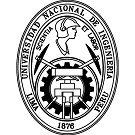
---
# TEMA: Análisis multicanal de archivo EDF 

---

#

### [1] Descarga de la librerias requeridas MNE, pandas,PyQt5

In [11]:
#instalacion de paquetes para la lectura de los archivos.edf
import sys
print(sys.executable)

!{sys.executable} -m pip install mne
!{sys.executable} -m pip install pandas
#!pip install pandas

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\python.exe



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#para diagramas iterativos
!pip install PyQt5

  Using cached PyQt5-5.15.11-cp38-abi3-win_amd64.whl.metadata (2.1 kB)
  Using cached PyQt5_Qt5-5.15.2-py3-none-win_amd64.whl.metadata (552 bytes)
Using cached PyQt5-5.15.11-cp38-abi3-win_amd64.whl (6.9 MB)
Using cached PyQt5_Qt5-5.15.2-py3-none-win_amd64.whl (50.1 MB)

   ---------------------------------------- 0/3 [PyQt5-Qt5]
   ---------------------------------------- 0/3 [PyQt5-Qt5]
   ---------------------------------------- 0/3 [PyQt5-Qt5]
   ---------------------------------------- 0/3 [PyQt5-Qt5]
   ---------------------------------------- 0/3 [PyQt5-Qt5]
   ---------------------------------------- 0/3 [PyQt5-Qt5]
   ---------------------------------------- 0/3 [PyQt5-Qt5]
   ---------------------------------------- 0/3 [PyQt5-Qt5]
   ---------------------------------------- 0/3 [PyQt5-Qt5]
   ---------------------------------------- 0/3 [PyQt5-Qt5]
   -------------------------- ------------- 2/3 [PyQt5]
   -------------------------- ------------- 2/3 [PyQt5]
   --------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Usuario\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [3]:
!pip install ipywidgets

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 914.9/914.9 kB 14.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 13.8 MB/s  0:00:00

   ------------- -------------------------- 1/3 [jupyterlab_widgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Usuario\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


### [2] Revision del listado de pacientes que se tiene la data para estudio

In [5]:
import pandas as pd

# Ruta del archivo CSV con la información general
#csv_path = r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\subject_info.csv"
csv_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\subject_info.csv"

# Cargar tabla de pacientes
df = pd.read_csv(csv_path)

print("==== LISTA DE PACIENTES DISPONIBLES ====")
for i, row in df.iterrows():
    print(f"Paciente {i} -> {row['patient_id']}")

df

==== LISTA DE PACIENTES DISPONIBLES ====
Paciente 0 -> PN00
Paciente 1 -> PN01
Paciente 2 -> PN03
Paciente 3 -> PN05
Paciente 4 -> PN06
Paciente 5 -> PN07
Paciente 6 -> PN09
Paciente 7 -> PN10
Paciente 8 -> PN11
Paciente 9 -> PN12
Paciente 10 -> PN13
Paciente 11 -> PN14
Paciente 12 -> PN16
Paciente 13 -> PN17


,patient_id,age_years,gender,seizure,localization,lateralization,eeg_channel,number_seizures,rec_time_minutes
0,PN00,55,Male,IAS,T,R,29,5,198
1,PN01,46,Male,IAS,T,L,29,2,809
2,PN03,54,Male,IAS,T,R,29,2,752
3,PN05,51,Female,IAS,T,L,29,3,359
4,PN06,36,Male,IAS,T,L,29,5,722
5,PN07,20,Female,IAS,T,L,29,1,523
6,PN09,27,Female,IAS,T,L,29,3,410
7,PN10,25,Male,FBTC,F,Bilateral,20,10,1002
8,PN11,58,Female,IAS,T,R,29,1,145
9,PN12,71,Male,IAS,T,L,29,4,246


### [3] Visualizacion de los episodios de paciente selecionado

---

### Paciente Selecionado --> PN0

Cambiar la ruta para ver los episodios del paciente selecionado

\PN0__\Seizures-list-PN0__.txt

---

In [6]:
import re
from datetime import time

#txt_path = r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\Seizures-list-PN00.txt"
txt_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\Seizures-list-PN00.txt"



def parse_time(t):
    """Convierte formatos tipo '19.39.33' a (segundos, objeto time)."""
    t = t.strip()
    h, m, s = t.split(".")
    h = int(h); m = int(m); s = int(s)
    seconds = h*3600 + m*60 + s
    hora_obj = time(h, m, s)
    return seconds, hora_obj

seizures = []
current = {}

with open(txt_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if line.startswith("Seizure n"):
            if current:
                seizures.append(current)

            # Extraer número aunque venga como "n1" o "n 1"
            parte = line.split()[-1]   # puede ser "1" o "n1"
            num = re.sub(r"\D", "", parte)  # quita todo lo que no es dígito

            if num == "":
                raise ValueError(f"No pude extraer número de: {line}")

            current = {"n": int(num)}

        elif line.startswith("File name:"):
            current["edf"] = line.split(":")[1].strip()

        elif line.startswith("Registration start time:"):
            t_str = line.split(":")[1].strip()
            secs, hora = parse_time(t_str)
            current["reg_start"] = secs
            current["reg_start_h"] = hora

        elif line.startswith("Registration end time:"):
            t_str = line.split(":")[1].strip()
            secs, hora = parse_time(t_str)
            current["reg_end"] = secs
            current["reg_end_h"] = hora

        elif line.startswith("Seizure start time:"):
            t_str = line.split(":")[1].strip()
            secs, hora = parse_time(t_str)
            current["sei_start"] = secs
            current["sei_start_h"] = hora

        elif line.startswith("Seizure end time:"):
            t_str = line.split(":")[1].strip()
            secs, hora = parse_time(t_str)
            current["sei_end"] = secs
            current["sei_end_h"] = hora

if current:
    seizures.append(current)

# Calcular tiempos relativos
for s in seizures:
    s["relative_start_sec"] = s["sei_start"] - s["reg_start"]
    s["relative_end_sec"]  = s["sei_end"] - s["reg_start"]
    s["duration_sec"]      = s["relative_end_sec"] - s["relative_start_sec"]

# Imprimir todo
for s in seizures:
    print("========================================================")
    print(f"Seizure n°:                        {s['n']}")
    print(f"EDF file:                          {s['edf']}")

    print("\n--- REGISTRO (toma de muestra EEG) ---")
    print(f"Inicio registro (hora real):       {s['reg_start_h']}")
    print(f"Fin registro (hora real):          {s['reg_end_h']}")
    print(f"Inicio registro (abs seg):         {s['reg_start']} s")
    print(f"Fin registro (abs seg):            {s['reg_end']} s")

    print("\n--- EPISODIO EPILÉPTICO ---")
    print(f"Inicio episodio (hora real):       {s['sei_start_h']}")
    print(f"Fin episodio (hora real):          {s['sei_end_h']}")
    print(f"Inicio episodio (abs seg):         {s['sei_start']} s")
    print(f"Fin episodio (abs seg):            {s['sei_end']} s")

    print("")
    print(f"Inicio episodio (relativo):        {s['relative_start_sec']} s")
    print(f"Fin episodio (relativo):           {s['relative_end_sec']} s")
    print(f"Duración del episodio:             {s['duration_sec']} s")
    print("========================================================")


Seizure n°:                        1
EDF file:                          PN00-1.edf

--- REGISTRO (toma de muestra EEG) ---
Inicio registro (hora real):       19:39:33
Fin registro (hora real):          20:22:58
Inicio registro (abs seg):         70773 s
Fin registro (abs seg):            73378 s

--- EPISODIO EPILÉPTICO ---
Inicio episodio (hora real):       19:58:36
Fin episodio (hora real):          19:59:46
Inicio episodio (abs seg):         71916 s
Fin episodio (abs seg):            71986 s

Inicio episodio (relativo):        1143 s
Fin episodio (relativo):           1213 s
Duración del episodio:             70 s
Seizure n°:                        2
EDF file:                          PN00-2.edf

--- REGISTRO (toma de muestra EEG) ---
Inicio registro (hora real):       02:18:17
Fin registro (hora real):          02:56:19
Inicio registro (abs seg):         8297 s
Fin registro (abs seg):            10579 s

--- EPISODIO EPILÉPTICO ---
Inicio episodio (hora real):       02:38:37
Fin ep

### [4] Carga del archivo EDF y exploración de metadatos de un Episodio 

En esta sección se carga el archivo EDF usando `mne.io.read_raw_edf` y se inspecciona:

- Número de canales.
- Frecuencia de muestreo.
- Etiquetas de canales.
- Duración del registro.

En la ruta seleccionar, la ruta y el archivo .edf del episodio a analizar:

edf_path =  r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN0__\PN0__-__.edf"



---

Carga de la metadata

---

In [13]:
import mne
import numpy as np
import pandas as pd
#edf_path =  r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf"
edf_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf"


# Carga del archivo EDF
raw = mne.io.read_raw_edf(edf_path, preload=True)

print(raw)
print("\n######  INFO DETALLADA  ######")
print(raw.info)

# Información básica
sfreq = raw.info["sfreq"]               # frecuencia de muestreo
ch_names = raw.info["ch_names"]         # nombres de canales
n_channels = len(ch_names)              # número de canales
n_samples = raw.n_times                 # número de muestras por canal
duration_sec = n_samples / sfreq        # duración total en segundos

print("\nFrecuencia de muestreo (Hz):", sfreq)
print("Número de canales:", n_channels)
print("Número de muestras:", n_samples)
print("Duración (s):", duration_sec)
print("Primeros 10 canales:", ch_names[:min(10, n_channels)])


raw 

Extracting EDF parameters from D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1343999  =      0.000 ...  2624.998 secs...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_10328\2118295523.py:9: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_10328\2118295523.py:9: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_10328\2118295523.py:9: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


<RawEDF | PN00-1.edf, 35 x 1344000 (2625.0 s), ~358.9 MiB, data loaded>

######  INFO DETALLADA  ######
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG F3, EEG C3, EEG P3, EEG O1, EEG F7, EEG T3, EEG T5, ...
 chs: 35 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 2016-01-01 19:39:33 UTC
 nchan: 35
 projs: []
 sfreq: 512.0 Hz
 subject_info: <subject_info | his_id: >
>

Frecuencia de muestreo (Hz): 512.0
Número de canales: 35
Número de muestras: 1344000
Duración (s): 2625.0
Primeros 10 canales: ['EEG Fp1', 'EEG F3', 'EEG C3', 'EEG P3', 'EEG O1', 'EEG F7', 'EEG T3', 'EEG T5', 'EEG Fc1', 'EEG Fc5']


<RawEDF | PN00-1.edf, 35 x 1344000 (2625.0 s), ~358.9 MiB, data loaded>

---

Pasamos la data de un paciente a una matriz de numpy

---

In [14]:
# Obtiene los datos como matriz NumPy: shape = (n_channels, n_samples)
data, times = raw.get_data(return_times=True)

print("data.shape =", data.shape)
print("times.shape =", times.shape)
print("Tiempo inicial:", times[0], "s")
print("Tiempo final:", times[-1], "s")


data.shape = (35, 1344000)
times.shape = (1344000,)
Tiempo inicial: 0.0 s
Tiempo final: 2624.998046875 s


### Carga de librerias requeridas, y rura de archivo de estudio - Paciente 0

In [16]:
# Imports principales
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Para que los gráficos se vean dentro del notebook
%matplotlib inline

# Ruta del archivo EDF (la que tú indicaste)
#edf_path = r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf"
edf_path = r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf"
# Configuración de logs de MNE
mne.set_log_level("INFO")

print("Ruta EDF:", edf_path)

Ruta EDF: D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf


## [5] Visualización dinamica de todos los canales con todos los puntos

A continuación, se construye una figura de Matplotlib con todas las señales, la navegacion en ella es dinamica


In [17]:
# Gráfico interactivo de todos los canales
# Puedes ajustar `duration` (ventana en segundos) y `n_channels` visibles en pantalla.
%matplotlib qt
raw.plot(duration=10.0, n_channels=n_channels, scalings="auto");


Using matplotlib as 2D backend.


Channels marked as bad:
[np.str_('EEG T4')]


## [6] Visualización estática de todos los canales con todos los puntos

A continuación, se construye una figura de Matplotlib con:

- Un subplot por canal.
- Eje x = tiempo (segundos).
- Eje y = amplitud de la señal (unidades del EDF).

In [18]:
import mne
import matplotlib.pyplot as plt

raw = mne.io.read_raw_edf(edf_path, preload=True)
data, times = raw.get_data(), raw.times
ch_names = raw.ch_names
n_channels = data.shape[0]

fig, axes = plt.subplots(
    n_channels, 1,
    figsize=(24, 14),
    sharex=True
)

for i in range(n_channels):
    axes[i].plot(times, data[i], linewidth=0.8)
    axes[i].set_ylabel(ch_names[i], rotation=0, labelpad=40)

# Ajustes por defecto que deseas
plt.subplots_adjust(
    top=0.955,
    bottom=0.055,
    left=0.05,
    right=0.995,
    hspace=0.200,
    wspace=0.200
)

# Quitar los números del eje Y
for ax in axes:
    ax.set_yticks([])
    ax.tick_params(axis='y', length=0)

plt.xlabel("Tiempo [s]")
plt.suptitle("Todos los canales con todos los puntos", fontsize=16)
plt.show()


Extracting EDF parameters from D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00\PN00-1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1343999  =      0.000 ...  2624.998 secs...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_10328\4282602163.py:4: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_10328\4282602163.py:4: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_10328\4282602163.py:4: RuntimeWarning: Highpass cutoff frequency 15.91549 is greater than lowpass cutoff frequency 15.0, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


## [7] Estadísticas básicas por canal

Se calculan:

- Media por canal.
- Desviación estándar por canal.
- Valor mínimo y máximo.

Esto da una primera idea de la escala de cada canal y posibles artefactos.


In [19]:
# Estadísticas básicas por canal
means = data.mean(axis=1)
stds = data.std(axis=1)
mins = data.min(axis=1)
maxs = data.max(axis=1)

stats_df = pd.DataFrame({
    "canal": ch_names,
    "media": means,
    "desviacion_std": stds,
    "minimo": mins,
    "maximo": maxs
})

stats_df




,canal,media,desviacion_std,minimo,maximo
0,EEG Fp1,4.803523e-06,3.403837e-05,-0.000710,0.000795
1,EEG F3,5.318128e-06,2.645774e-05,-0.000602,0.000633
2,EEG C3,3.131167e-06,2.904585e-05,-0.000569,0.000300
3,EEG P3,3.990579e-06,4.022246e-05,-0.000657,0.000991
4,EEG O1,3.663936e-06,1.060350e-04,-0.001187,0.003182
5,EEG F7,7.100435e-06,4.015560e-05,-0.000654,0.000354
6,EEG T3,4.914065e-06,3.526235e-05,-0.000714,0.000315
7,EEG T5,8.439295e-06,2.891023e-05,-0.000486,0.000333
8,EEG Fc1,5.140642e-06,2.755394e-05,-0.000619,0.000281
9,EEG Fc5,2.877245e-06,3.152580e-05,-0.000596,0.000364


## [8] Selección de Canales Representativos para la Detección de Crisis Epilépticas

La electroencefalografía (EEG) registra diferencias de potencial en el cuero cabelludo mediante una red
de electrodos organizados usualmente bajo el sistema internacional **10–20** o sus extensiones.
Cada electrodo proporciona una señal eléctrica en unidades de microvoltios (µV) que refleja la actividad
sincrónica de grandes poblaciones neuronales corticales.

En el análisis de episodios epilépticos, no todos los canales aportan la misma relevancia clínica.
La elección de *canales representativos* se basa en la neurofisiología de los generadores de descargas
epileptiformes y en la localización típica de los focos más comunes.  
A continuación se justifica la selección utilizada.

### 1. Canales temporales (T3, T4, T5, T6)

Los lóbulos temporales son la región más frecuentemente asociada a la epilepsia focal,
especialmente en el caso de la **epilepsia del lóbulo temporal (TLE)**.  
Por ello, los canales:
- `T3` y `T5` en el hemisferio izquierdo,
- `T4` y `T6` en el hemisferio derecho,

constituyen los electrodos más sensibles para detectar:
- complejos punta–onda,
- actividad rítmica tipo theta o delta,
- ondas agudas y polipuntas,
- cambios electrográficos súbitos de alta amplitud.

Por esta razón, estos canales son los **más representativos** para la observación de crisis.

### 2. Canales frontales (Fp1, Fp2, F3, F4, F7, F8)

La región frontal participa en:
- diseminación rápida de la actividad epileptiforme,
- crisis motoras de inicio frontal,
- cambios de alta frecuencia al inicio ictal.

Los canales prefrontales (`Fp1`, `Fp2`) y frontales (`F3`, `F4`, `F7`, `F8`)
permiten detectar:
- actividad rítmica de alta frecuencia,
- patrones de reclutamiento,
- propagación anterior de actividad temporal.

Aunque no siempre son los generadores primarios, aportan un contexto espacial esencial
para la identificación del inicio y diseminación de la crisis.

### 3. Canales centrales (C3, C4, Cz)

Los electrodos centrales se ubican sobre la corteza somatosensorial.
Son útiles para:
- crisis motoras,
- propagación rápida hacia áreas perisilvianas,
- análisis de simetría interhemisférica.

En casos de crisis focales que se diseminan hacia corteza motora, estos canales
presentan incrementos claros en amplitud o ritmicidad.

### 4. Canales parietales (P3, P4, Pz)

Los electrodos parietales ofrecen sensibilidad a:
- propagación posterior,
- patrones de realce parieto–occipital,
- descargas secundarias de actividad temporal o frontal.

La observación de estos canales permite contextualizar el origen y la dirección
del flujo eléctrico cortical durante la crisis.

### 5. Canales occipitales (O1, O2)

Aunque la epilepsia occipital es menos frecuente que la temporal o frontal,
los electrodos `O1` y `O2` son relevantes porque:
- revelan descargas punta–onda posteriores,
- ayudan a verificar si una crisis detectada es generalizada o focal posterior,
- permiten evaluar si existe propagación hacia la región visual.

### 6. Fundamentación de la selección final

Dado que el objetivo del análisis es **detectar y visualizar episodios epilépticos**,
se priorizan los canales que clínicamente aportan mayor sensibilidad:

- **Temporales:** máxima prioridad por su asociación directa con epilepsia focal.
- **Frontales:** esenciales para identificar propagación anterior e inicio frontal.
- **Centrales:** útiles para crisis motoras y para interpretar simetrías.
- **Parietales:** permiten evaluar propagación posterior.
- **Occipitales:** completan el mapa espacial, especialmente para descargas posteriores.

Esta selección proporciona una representación espacial completa y eficiente del comportamiento
ictal y preictal sin necesidad de graficar la totalidad de canales disponibles.


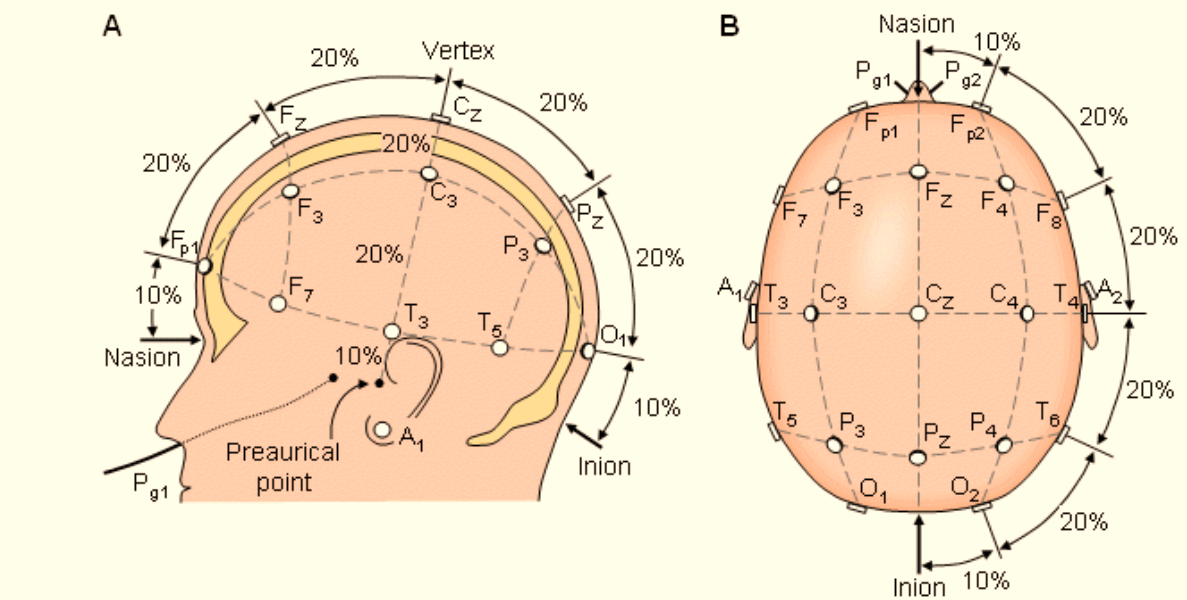


---

Ploteo de todos los registros representativos del paciente selecionado, marcando el inicio y final del episodio

---

In [ ]:
import os
import re
import mne
import numpy as np
import matplotlib.pyplot as plt
# Para que los gráficos se vean dentro del notebook
%matplotlib inline

# ---------------------------------------------------------------------
# RUTAS
# ---------------------------------------------------------------------
base_path = r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00"

txt_path = os.path.join(base_path, "Seizures-list-PN00.txt")

# ---------------------------------------------------------------------
# LEER ARCHIVO DE TEXTOS
# ---------------------------------------------------------------------
def parse_time_hms_with_dots(t):
    t = t.strip()
    h, m, s = t.split(".")
    return int(h) * 3600 + int(m) * 60 + int(s)

seizures = []
current = None

with open(txt_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        if line.startswith("Seizure n"):
            if current is not None:
                seizures.append(current)
            m = re.search(r"Seizure n\s+(\d+)", line)
            current = {"n": int(m.group(1))}

        elif line.startswith("File name:"):
            current["file_name"] = line.split(":")[1].strip()

        elif line.startswith("Registration start time"):
            current["reg_start"] = line.split(":")[1].strip()

        elif line.startswith("Registration end time"):
            current["reg_end"] = line.split(":")[1].strip()

        elif line.startswith("Seizure start time"):
            current["seiz_start"] = line.split(":")[1].strip()

        elif line.startswith("Seizure end time"):
            current["seiz_end"] = line.split(":")[1].strip()

if current is not None:
    seizures.append(current)

# ---------------------------------------------------------------------
# CANALES REPRESENTATIVOS (12 CANALES)
# ---------------------------------------------------------------------
REP_CHANNELS = [
    "EEG T3", "EEG T4", "EEG T5", "EEG T6",      # Temporales (4)
    "EEG Fp1", "EEG Fp2", "EEG F7", "EEG F8",    # Frontales (4)
    "EEG C3", "EEG C4",                          # Centrales  (2)
    "EEG P3", "EEG P4"                           # Parietales (2)
]  # Total = 12

# ---------------------------------------------------------------------
# FUNCIÓN PARA GRAFICAR TODO EL REGISTRO Y MARCAR CRISIS
# ---------------------------------------------------------------------
def plot_full_record_with_markers(entry, base_path=base_path, rep_channels=REP_CHANNELS):

    file_name = entry["file_name"]
    edf_path = os.path.join(base_path, file_name)

    print(f"\nGraficando Seizure {entry['n']} en archivo {file_name}")

    # Convertir horas a segundos absolutos
    reg_start = parse_time_hms_with_dots(entry["reg_start"])
    seiz_start = parse_time_hms_with_dots(entry["seiz_start"])
    seiz_end = parse_time_hms_with_dots(entry["seiz_end"])

    # tiempos relativos dentro del EDF
    rel_start = seiz_start - reg_start
    rel_end   = seiz_end   - reg_start

    # CARGAR EDF COMPLETO
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    sfreq = raw.info["sfreq"]

    print("Frecuencia:", sfreq, "Hz")
    print("Canales EDF:", raw.ch_names)

    # FILTRAR SOLO LOS 12 CANALES REPRESENTATIVOS QUE EXISTEN
    available = [ch for ch in rep_channels if ch in raw.ch_names]
    raw_sel = raw.copy().pick(available)

    # EXTRAER DATOS COMPLETOS
    data, times = raw_sel.get_data(return_times=True)
    n_ch = len(available)

    # -----------------------------------------------------------
    # GRAFICAR SERIE COMPLETA + LÍNEAS VERDES
    # -----------------------------------------------------------
    fig, axes = plt.subplots(n_ch, 1, figsize=(15, 2*n_ch), sharex=True)

    if n_ch == 1:
        axes = [axes]

    for i, ch in enumerate(available):
        ax = axes[i]
        ax.plot(times, data[i], linewidth=0.8)

        # Líneas verdes
        ax.axvline(rel_start, color="green", linestyle="--", linewidth=2, label="Inicio crisis" if i==0 else None)
        ax.axvline(rel_end, color="green", linestyle="-", linewidth=2, label="Fin crisis" if i==0 else None)

        ax.set_ylabel(ch, rotation=0, labelpad=25)
        ax.grid(True, linestyle=":", linewidth=0.5)

        if i == 0:
            ax.set_title(
                f"Paciente PN00 — Seizure {entry['n']} — {file_name}\n"
                f"Crisis: {entry['seiz_start']} → {entry['seiz_end']}"
            )

    axes[-1].set_xlabel("Tiempo (s)")
    axes[0].legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# GENERAR LAS 5 FIGURAS (UNA POR EPISODIO)
# ---------------------------------------------------------------------
for entry in seizures:
    plot_full_record_with_markers(entry)


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\CICLO 2025-2 UNI\\PROGRAMACION_PARALELA\\PROGRAMACION_PARALELA_CODIGO\\TRABAJO INVESTIGACION PARALELA\\Codigo\\data\\PN00\\Seizures-list-PN00.txt'

In [ ]:
import mne
import os

edf_dir = r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00"

# ---------- ENTRENAMIENTO ----------
train_files = ["PN00-1.edf", "PN00-2.edf"]
raws_train = [mne.io.read_raw_edf(os.path.join(edf_dir, f),
                                  stim_channel="Event marker",
                                  infer_types=True,
                                  preload=True,
                                  verbose="error") for f in train_files]
raw_train = mne.concatenate_raws(raws_train) # esto une los archivos PN00-1 y PN00-2 en una sola señal en la forma (n_channels​,n_samples1​​+n_samples2​​)
print("✅ raw_train shape:", raw_train.get_data().shape)

# ---------- PRUEBA ----------
test_files = ["PN00-4.edf"]
raws_test = [mne.io.read_raw_edf(os.path.join(edf_dir, f),
                                 stim_channel="Event marker",
                                 infer_types=True,
                                 preload=True,
                                 verbose="error") for f in test_files]
raw_test = mne.concatenate_raws(raws_test)
print("✅ raw_test shape:", raw_test.get_data().shape)

# ---------- REEVALUACIÓN ----------
retest_files = [ "PN00-5.edf"]
raws_retest = [mne.io.read_raw_edf(os.path.join(edf_dir, f),
                                   stim_channel="Event marker",
                                   infer_types=True,
                                   preload=True,
                                   verbose="error") for f in retest_files]
raw_retest = mne.concatenate_raws(raws_retest).get_data()
print("✅ raw_retest shape:", raw_retest.shape)


✅ raw_train shape: (35, 2522624)
✅ raw_test shape: (35, 1076224)
✅ raw_retest shape: (35, 1097216)


In [16]:
# Variables
sfreq = int(raw_train.info["sfreq"])
datatrain = raw_train.get_data()
Ntrain = int(max(datatrain.shape)/sfreq)
datatest = raw_test.get_data()
Ntest = int(max(datatest.shape)/sfreq)
secondeventscrisis = np.array([106,411,990,1192])
secondeventscrisistest = np.array([409, 593, 1050])
lowpass = raw_train.info["lowpass"]
ch_names = raw_train.ch_names
n_chan = len(ch_names)
Fp1_F7,F7_T3,T3_T5,T5_O1,Fp1_F3,F3_C3,C3_P3,P3_O1,Fz_Cz,Cz_Pz,Fp2_F4,F4_C4,C4_P4,P4_O2,Fp2_F8,F8_T4,T4_T6,T6_O2= 0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
raw_train.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, F3, C3, P3, O1, F7, T3, T5, Fc1, Fc5, Cp1, Cp5, F9, Fz, Cz, ...
 chs: 35 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 2016-01-01 19:39:33 UTC
 nchan: 35
 projs: []
 sfreq: 512.0 Hz
 subject_info: <subject_info | his_id: >
>